<a href="https://colab.research.google.com/github/haslena123/SESSION-8/blob/main/Salinan_dari_SESI_7_with_Alif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HANDS-ON SESSION 7
## Python + Google Colab + BigQuery — Data Cleaning & EDA TheLook Ecommerce

**Dataset:** `bigquery-public-data.thelook_ecommerce`  
**Level:** Basic / Pemula

### Alur Project
**BigQuery → Pandas → Cleaning → EDA → Insight**

Dataset tetap menggunakan TheLook Ecommerce agar project berkesinambungan dari sesi sebelumnya.

> Pada sesi ini fokusnya adalah **data cleaning dan exploratory data analysis (EDA) sederhana**. Tidak menggunakan JOIN kompleks.


## 1. Setup Google Colab & BigQuery

In [ ]:
!pip -q install google-cloud-bigquery db-dtypes


In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = "lenas-projects"
client = bigquery.Client(project=PROJECT_ID)

print("Connected to:", PROJECT_ID)


Connected to: lenas-projects


## 2. Cek Dataset TheLook Ecommerce

In [ ]:
query = '''

SELECT
  table_name
FROM `bigquery-public-data.thelook_ecommerce.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name

'''

client.query(query).to_dataframe()


,table_name
0,distribution_centers
1,events
2,inventory_items
3,order_items
4,orders
5,products
6,users


# BAGIAN A — AMBIL DATA DARI BIGQUERY

## 3. Ambil Data Orders

Kita gunakan tabel `orders` sebagai dataset utama.


In [ ]:
syntax_sql = """
SELECT
*
FROM `bigquery-public-data.thelook_ecommerce.orders`
LIMIT 5
"""

In [ ]:
hasil_query = client.query(syntax_sql).to_dataframe()

In [ ]:
(hasil_query)

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item
0,1,1,Cancelled,F,2024-10-05 08:46:45+00:00,NaT,NaT,NaT,1
1,2,1,Cancelled,F,2023-07-09 16:17:38+00:00,NaT,NaT,NaT,1
2,36,21,Cancelled,F,2022-11-25 11:26:14+00:00,NaT,NaT,NaT,1
3,65,47,Cancelled,F,2025-06-10 13:51:49+00:00,NaT,NaT,NaT,2
4,117,85,Cancelled,F,2024-05-24 17:31:11+00:00,NaT,NaT,NaT,1


In [ ]:
query = '''
SELECT
  order_id,
  user_id,
  status,
  created_at
FROM `bigquery-public-data.thelook_ecommerce.orders`
'''

df = client.query(query).to_dataframe()
display(df)

,order_id,user_id,status,created_at
0,1,1,Cancelled,2024-10-05 08:46:45+00:00
1,2,1,Cancelled,2023-07-09 16:17:38+00:00
2,36,21,Cancelled,2022-11-25 11:26:14+00:00
3,65,47,Cancelled,2025-06-10 13:51:49+00:00
4,117,85,Cancelled,2024-05-24 17:31:11+00:00
...,...,...,...,...
124809,124805,99995,Shipped,2026-06-28 02:27:07+00:00
124810,124807,99997,Shipped,2023-07-24 03:16:21+00:00
124811,124808,99997,Shipped,2026-02-12 07:56:42+00:00
124812,124809,99998,Shipped,2024-09-20 05:25:42+00:00


### Tampilkan kolom id, email, age, gender dari data tabel user

In [ ]:
myquery = '''
SELECT
   id,
  email,
  age,
  gender
FROM `bigquery-public-data.thelook_ecommerce.users`
'''

result = client.query(myquery).to_dataframe()
result

,id,email,age,gender
0,40405,joshuabrown@example.net,12,M
1,25346,beverlymitchell@example.com,12,F
2,21761,jasmineprice@example.net,12,F
3,70447,deboraholson@example.com,12,F
4,99678,sarahjames@example.net,12,F
...,...,...,...,...
99995,87003,troyalvarez@example.net,70,M
99996,73328,nicholashernandez@example.com,70,M
99997,59949,nancycollins@example.net,70,F
99998,79172,heatherallen@example.net,70,F


In [ ]:
df.shape

(124814, 4)

In [ ]:

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 124814
Columns: 4


## 4. Melihat Data Awal

In [ ]:
df.head(10)


,order_id,user_id,status,created_at
0,1,1,Cancelled,2024-10-05 08:46:45+00:00
1,2,1,Cancelled,2023-07-09 16:17:38+00:00
2,36,21,Cancelled,2022-11-25 11:26:14+00:00
3,65,47,Cancelled,2025-06-10 13:51:49+00:00
4,117,85,Cancelled,2024-05-24 17:31:11+00:00
5,121,89,Cancelled,2026-07-24 08:38:12+00:00
6,124,93,Cancelled,2025-08-30 09:08:07+00:00
7,125,94,Cancelled,2025-12-22 10:16:40+00:00
8,131,101,Cancelled,2026-02-14 03:04:00+00:00
9,170,127,Cancelled,2026-09-01 19:48:12+00:00


# BAGIAN B — DATA UNDERSTANDING

## 5. Cek Struktur Data

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124814 entries, 0 to 124813
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype              
---  ------      --------------   -----              
 0   order_id    124814 non-null  Int64              
 1   user_id     124814 non-null  Int64              
 2   status      124814 non-null  object             
 3   created_at  124814 non-null  datetime64[us, UTC]
dtypes: Int64(2), datetime64[us, UTC](1), object(1)
memory usage: 4.0+ MB


## 6. Cek Jumlah Baris dan Kolom

In [ ]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])


Jumlah baris : 124814
Jumlah kolom : 4


## 7. Cek Missing Value

Hitung nilai kosong setiap kolom.


In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
order_id,0
user_id,0
status,0
created_at,0


## filter / memunculkan data yang kosong

In [ ]:
df.isna()\
.any(axis=1)

,0
0,False
1,False
2,False
3,False
4,False
...,...
124809,False
124810,False
124811,False
124812,False


### insight


tidak terdapat data yang kosong

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing


,0
order_id,0
user_id,0
status,0
created_at,0


## 8. Cek Duplicate

In [ ]:
duplicated_row = df.duplicated().sum()
print (duplicated_row)

0


In [ ]:
duplicate_count = df.duplicated().sum()

print("Jumlah duplicate:", duplicate_count)


Jumlah duplicate: 0


# BAGIAN C — DATA CLEANING

## 9. Menghapus Duplicate & Menghapus data kosong

Untuk dataset latihan, duplicate dapat dihapus jika memang bukan record transaksi yang berbeda.


In [ ]:
df = df.drop_duplicates()
df.shape

(124814, 4)

In [ ]:
from re import A
kondisi_data = df.shape #[x,y] (x,y) tuple
print("Kondisi awal kolom dan baris : " ,df.shape)

print(kondisi_data)

df = df.drop_duplicates()
df = df.dropna()

after = df.shape

print("Sebelum :", df.shape )
print("Sesudah :", after)
print("Dihapus :", kondisi_data[0] - after[0] )


Kondisi awal kolom dan baris :  (124814, 4)
(124814, 4)
Sebelum : (124814, 4)
Sesudah : (124814, 4)
Dihapus : 0


In [ ]:
# hapus missing value
df = df.dropna()

## 10. Cleaning Kolom Tanggal

Pastikan `created_at` bertipe datetime.


In [ ]:
df['created_at']

,created_at
0,2024-10-05 08:46:45+00:00
1,2023-07-09 16:17:38+00:00
2,2022-11-25 11:26:14+00:00
3,2025-06-10 13:51:49+00:00
4,2024-05-24 17:31:11+00:00
...,...
124809,2026-06-28 02:27:07+00:00
124810,2023-07-24 03:16:21+00:00
124811,2026-02-12 07:56:42+00:00
124812,2024-09-20 05:25:42+00:00


In [ ]:
import pandas as pd
df["created_at"] = pd.to_datetime(
    df["created_at"],
    errors="coerce",

)

print(df["created_at"].dtype)


datetime64[us, UTC]


In [ ]:
df.head()

,order_id,user_id,status,created_at
0,1,1,Cancelled,2024-10-05 08:46:45+00:00
1,2,1,Cancelled,2023-07-09 16:17:38+00:00
2,36,21,Cancelled,2022-11-25 11:26:14+00:00
3,65,47,Cancelled,2025-06-10 13:51:49+00:00
4,117,85,Cancelled,2024-05-24 17:31:11+00:00


## 11. Cek Missing Setelah Konversi Tanggal

In [ ]:
df["created_at"].isna().sum()


np.int64(0)

## 12. Membuat Kolom Tanggal

Kolom `order_date` akan berguna untuk analisis harian.


In [ ]:
df['order_date'] = df[ 'created_at' ].dt.date
df.head()

,order_id,user_id,status,created_at,order_date
0,1,1,Cancelled,2024-10-05 08:46:45+00:00,2024-10-05
1,2,1,Cancelled,2023-07-09 16:17:38+00:00,2023-07-09
2,36,21,Cancelled,2022-11-25 11:26:14+00:00,2022-11-25
3,65,47,Cancelled,2025-06-10 13:51:49+00:00,2025-06-10
4,117,85,Cancelled,2024-05-24 17:31:11+00:00,2024-05-24


In [ ]:
#Buat kolom jam transaksi

In [ ]:
df['trx_hour'] = df[ 'created_at' ].dt.time
df.head()

,order_id,user_id,status,created_at,order_date,order_hour,trx_hour
0,1,1,Cancelled,2024-10-05 08:46:45+00:00,2024-10-05,8,08:46:45
1,2,1,Cancelled,2023-07-09 16:17:38+00:00,2023-07-09,16,16:17:38
2,36,21,Cancelled,2022-11-25 11:26:14+00:00,2022-11-25,11,11:26:14
3,65,47,Cancelled,2025-06-10 13:51:49+00:00,2025-06-10,13,13:51:49
4,117,85,Cancelled,2024-05-24 17:31:11+00:00,2024-05-24,17,17:31:11


## 13. Validasi Status

Lihat kategori status yang tersedia.


In [ ]:
df["status"].value_counts(dropna=False)


,count
status,
Shipped,37201
Complete,31148
Processing,24901
Cancelled,18969
Returned,12595


# BAGIAN D — EDA DASAR (exploratory data analysis)

## 14. Total Orders

In [ ]:
total_orders = len(df)

print("Total Orders:", total_orders)


Total Orders: 124814


## 15. Orders per Status

In [ ]:
df["status"]\
      .value_counts().reset_index()

,status,count
0,Shipped,37201
1,Complete,31148
2,Processing,24901
3,Cancelled,18969
4,Returned,12595


In [ ]:
df.columns

Index(['order_id', 'user_id', 'status', 'created_at', 'order_date',
       'order_hour', 'trx_hour', 'status upper'],
      dtype='object')

In [ ]:
status_summary = (
    df["status"]
      .value_counts()
      .reset_index()
)

status_summary.columns = [
    "status",
    "total_orders"
]

status_summary


,status,total_orders
0,Shipped,37201
1,Complete,31148
2,Processing,24901
3,Cancelled,18969
4,Returned,12595


In [ ]:
df[df['status']== 'Shipped']

## 16. Complete Orders

In [ ]:
(df["status"] == "Cancelled").sum()

np.int64(18969)

In [ ]:
df["status"] == "Complete"

,status
0,False
1,False
2,False
3,False
4,False
...,...
124809,False
124810,False
124811,False
124812,False


In [ ]:
complete_orders = (df["status"] == "Complete").sum()

print("Complete Orders:", complete_orders)


Complete Orders: 31148


## 17. Complete Rate

In [ ]:
complete_rate = round(
    complete_orders / total_orders * 100,
    2
)

print("Complete Rate:", complete_rate, "%")


Complete Rate: 24.96 %


## insight

transaksi order complete memiliki proporsi 25% dari total order yang terjadi

In [ ]:
#anggep ini lagi menjumlah yang berkaitan dengan nominal

df['total'] = df['order_id'] * df['user_id']

df

,order_id,user_id,status,created_at,order_date,order_hour,trx_hour,status upper,total
0,1,1,Cancelled,2024-10-05 08:46:45+00:00,2024-10-05,8,08:46:45,CANCELLED,1
1,2,1,Cancelled,2023-07-09 16:17:38+00:00,2023-07-09,16,16:17:38,CANCELLED,2
2,36,21,Cancelled,2022-11-25 11:26:14+00:00,2022-11-25,11,11:26:14,CANCELLED,756
3,65,47,Cancelled,2025-06-10 13:51:49+00:00,2025-06-10,13,13:51:49,CANCELLED,3055
4,117,85,Cancelled,2024-05-24 17:31:11+00:00,2024-05-24,17,17:31:11,CANCELLED,9945
...,...,...,...,...,...,...,...,...,...
124809,124805,99995,Shipped,2026-06-28 02:27:07+00:00,2026-06-28,2,02:27:07,SHIPPED,12479875975
124810,124807,99997,Shipped,2023-07-24 03:16:21+00:00,2023-07-24,3,03:16:21,SHIPPED,12480325579
124811,124808,99997,Shipped,2026-02-12 07:56:42+00:00,2026-02-12,7,07:56:42,SHIPPED,12480425576
124812,124809,99998,Shipped,2024-09-20 05:25:42+00:00,2024-09-20,5,05:25:42,SHIPPED,12480650382


## 18. Orders per Date

In [ ]:
status_summary
daily_orders = (
    df.groupby("order_date")
      .size()
      .reset_index(name="total_orders")
      .sort_values("total_orders", ascending=False)
)

daily_orders.head(10)


,order_date,total_orders
2751,2026-09-29,1780
2750,2026-09-28,977
2749,2026-09-27,779
2748,2026-09-26,536
2747,2026-09-25,413
2746,2026-09-24,301
2741,2026-09-19,277
2745,2026-09-23,275
2742,2026-09-20,259
2743,2026-09-21,259


## 19. Orders per Month

In [ ]:
df["month"] = (
    df["created_at"]
      .dt.to_period("M")
      .astype(str)
)

monthly_orders = (
    df.groupby("month")
      .size()
      .reset_index(name="total_orders")
)

monthly_orders.head(10)


/tmp/ipykernel_1840/1895575624.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


,month,total_orders
0,2019-01,6
1,2019-02,12
2,2019-03,34
3,2019-04,46
4,2019-05,57
5,2019-06,72
6,2019-07,88
7,2019-08,105
8,2019-09,125
9,2019-10,143


## 20. Visualisasi Monthly Orders

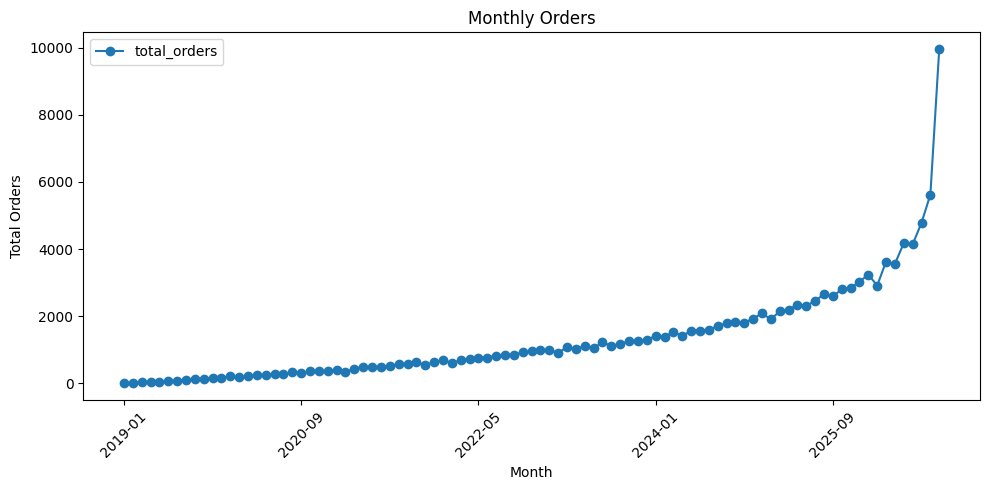

In [ ]:
import matplotlib.pyplot as plt

monthly_orders.plot(
    x="month",
    y="total_orders",
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
df = df.sort_values(ascending=True, by= 'created_at')

df['year'] = df['created_at'].dt.year
df['month'] = df['created_at'].dt.month
df['day'] = df['created_at'].dt.day

df

,order_id,user_id,status,created_at,order_date,order_hour,trx_hour,status upper,total,month,year,day
122331,108401,86904,Shipped,2019-01-11 07:24:04+00:00,2019-01-11,7,07:24:04,SHIPPED,9420480504,1,2019,11
65293,35940,28631,Cancelled,2019-01-15 07:34:34+00:00,2019-01-15,7,07:34:34,CANCELLED,1028998140,1,2019,15
121215,100879,80931,Shipped,2019-01-18 08:25:34+00:00,2019-01-18,8,08:25:34,SHIPPED,8164238349,1,2019,18
89944,24217,19358,Processing,2019-01-20 02:11:27+00:00,2019-01-20,2,02:11:27,PROCESSING,468792686,1,2019,20
64348,23774,18998,Cancelled,2019-01-21 06:27:30+00:00,2019-01-21,6,06:27:30,CANCELLED,451658452,1,2019,21
...,...,...,...,...,...,...,...,...,...,...,...,...
5970,78861,63117,Cancelled,2026-09-30 00:24:41.413349+00:00,2026-09-30,0,00:24:41.413349,CANCELLED,4977469737,9,2026,30
43433,114373,91571,Returned,2026-09-30 00:27:09.566869+00:00,2026-09-30,0,00:27:09.566869,RETURNED,10473249983,9,2026,30
24526,118991,95344,Complete,2026-09-30 00:29:23.427410+00:00,2026-09-30,0,00:29:23.427410,COMPLETE,11345077904,9,2026,30
9368,122191,97884,Cancelled,2026-09-30 00:29:38.292502+00:00,2026-09-30,0,00:29:38.292502,CANCELLED,11960543844,9,2026,30


## 21. Visualisasi Status

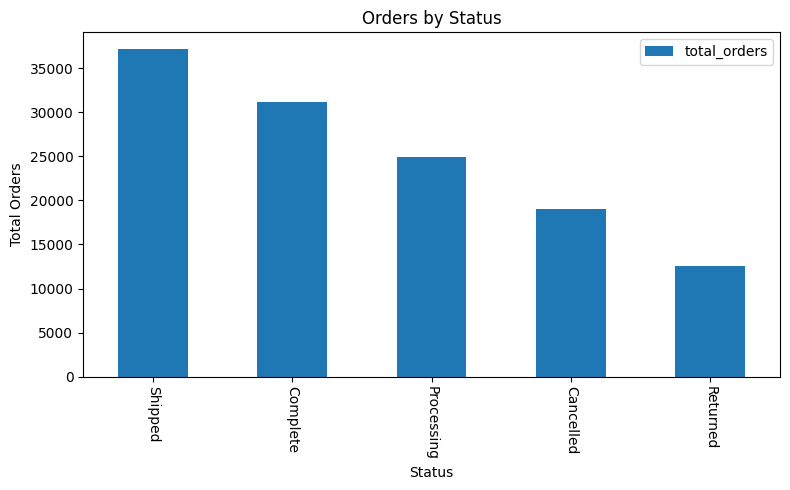

In [ ]:
status_summary.plot(
    x="status",
    y="total_orders",
    kind="bar",
    figsize=(8,5)
)

plt.title("Orders by Status")
plt.xlabel("Status")
plt.ylabel("Total Orders")
plt.xticks(rotation=-90)
plt.tight_layout()
plt.show()


# BAGIAN F — HANDS-ON CLEANING CHECK

## 23. Final Data Quality Check

In [ ]:
print("===== FINAL DATA QUALITY CHECK =====")
print("Rows            :", len(df))
print("Columns         :", len(df.columns))
print("Missing values  :", int(df.isna().sum().sum()))
print("Duplicate rows  :", int(df.duplicated().sum()))
print("Invalid dates   :", int(df["created_at"].isna().sum()))


===== FINAL DATA QUALITY CHECK =====
Rows            : 124814
Columns         : 12
Missing values  : 0
Duplicate rows  : 0
Invalid dates   : 0


## 24. Simpan Dataset Bersih

Dataset ini akan menjadi input untuk sesi berikutnya.


In [ ]:
clean_file = "thelook_clean_session7.csv"

df.to_csv(
    clean_file,
    index=False
)

print("File berhasil dibuat:", clean_file)


File berhasil dibuat: thelook_clean_session7.csv


In [ ]:
from google.colab import files

files.download("thelook_clean_session7.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# MINI PROJECT SESI 7

### Business Question
**“Bagaimana kondisi order TheLook Ecommerce setelah data dibersihkan?”**

Peserta harus menghasilkan:
- Clean dataset
- Total Orders
- Status Summary
- Complete Orders
- Complete Rate
- Daily Orders
- Monthly Orders
- Minimal 2 insight dari hasil EDA


# LATIHAN MANDIRI

### Soal 1
Cari 10 tanggal dengan jumlah order terbanyak.

### Soal 2
Cari bulan dengan jumlah order terbanyak.

### Soal 3
Hitung persentase masing-masing status.

### Soal 4
Buat satu visualisasi tambahan.

### Soal 5
Tuliskan minimal 2 insight berdasarkan data.

**Hint:** gunakan `groupby()`, `value_counts()`, `sort_values()`, dan filtering.


In [ ]:
# Tulis kode Anda di sini

# Contoh:
# hasil = df.groupby(...)
# hasil = hasil.sort_values(...)
# hasil


# OUTPUT & HANDOFF KE SESI 8

### Output Sesi 7
- Notebook Google Colab
- Dataset bersih `thelook_clean_session7.csv`
- Summary status
- Daily / monthly analysis
- Visualisasi dasar
- Minimal 2 insight

### Handoff
**Sesi 7: Cleaning + EDA**
↓
**Sesi 8: Analisis Python lanjutan**

Project tetap menggunakan dataset TheLook Ecommerce yang sama.


# JOIN

In [ ]:
df1 = pd.DataFrame({
    'employee': ['Alice', 'Bob', 'Charlie'],
    'dept_id': [1, 2, 1]
})

df2 = pd.DataFrame({
    'dept_name': ['Engineering', 'Sales']
}, index=[1, 2])

In [ ]:
df1.join(df2 , on='dept_id' , how='inner' )

In [ ]:
result = df1.join(df2, on='dept_id')

In [ ]:
queryOrders = '''
SELECT *
FROM `bigquery-public-data.thelook_ecommerce.orders`
'''

queryUser = '''
SELECT *
FROM `bigquery-public-data.thelook_ecommerce.users`
'''

In [ ]:
order = client.query(queryOrders).to_dataframe()
user = client.query(queryUser).to_dataframe()

In [ ]:
order.sample()

In [ ]:
user.sample()

In [ ]:
order.merge(user , left_on='user_id' , right_on = 'id' , how = 'inner')\
[['order_id','user_id','country']]